# Classificação - Churn

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from scipy.stats import chi2_contingency
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## Carregar Dados

In [140]:
df_leads = pd.read_csv("./dataset/leads.csv")
df_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   str    
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   str    
 3   Lead Source                                    9204 non-null   str    
 4   Do Not Email                                   9240 non-null   str    
 5   Do Not Call                                    9240 non-null   str    
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 non-null   

In [141]:
df_leads.head(5)

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


## Features Engineering e Data Cleaning - Variáveis Categóricas

### Remover as colunas de ID

In [142]:
df_leads.drop(columns=['Prospect ID', 'Lead Number'], inplace=True)

### Mostrar e remover as colunas categóricas que possuem somente um valor

In [143]:
for column in df_leads.select_dtypes(include='object').columns.tolist():
    if df_leads[column].nunique() == 1:
        print(f"Coluna {column} possui somente um único valor: '{df_leads[column].unique()[0]}'")
        df_leads.drop(columns=column, inplace=True)

Coluna Magazine possui somente um único valor: 'No'
Coluna Receive More Updates About Our Courses possui somente um único valor: 'No'
Coluna Update me on Supply Chain Content possui somente um único valor: 'No'
Coluna Get updates on DM Content possui somente um único valor: 'No'
Coluna I agree to pay the amount through cheque possui somente um único valor: 'No'


/tmp/ipykernel_304205/3601108241.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_leads.select_dtypes(include='object').columns.tolist():


### Mostrar dataset sem as colunas removidas

In [144]:
df_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 30 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lead Origin                                    9240 non-null   str    
 1   Lead Source                                    9204 non-null   str    
 2   Do Not Email                                   9240 non-null   str    
 3   Do Not Call                                    9240 non-null   str    
 4   Converted                                      9240 non-null   int64  
 5   TotalVisits                                    9103 non-null   float64
 6   Total Time Spent on Website                    9240 non-null   int64  
 7   Page Views Per Visit                           9103 non-null   float64
 8   Last Activity                                  9137 non-null   str    
 9   Country                                        6779 non-null   

### Mostrar valores de todas colunas categóricas

In [145]:
for column in df_leads.select_dtypes(include='object').columns.tolist():
    print(f"Valores da coluna {column}")
    for item in list(df_leads[column].unique()):
        print(item)
    print()

Valores da coluna Lead Origin
API
Landing Page Submission
Lead Add Form
Lead Import
Quick Add Form

Valores da coluna Lead Source
Olark Chat
Organic Search
Direct Traffic
Google
Referral Sites
Welingak Website
Reference
google
Facebook
nan
blog
Pay per Click Ads
bing
Social Media
WeLearn
Click2call
Live Chat
welearnblog_Home
youtubechannel
testone
Press_Release
NC_EDM

Valores da coluna Do Not Email
No
Yes

Valores da coluna Do Not Call
No
Yes

Valores da coluna Last Activity
Page Visited on Website
Email Opened
Unreachable
Converted to Lead
Olark Chat Conversation
Email Bounced
Email Link Clicked
Form Submitted on Website
Unsubscribed
Had a Phone Conversation
View in browser link Clicked
nan
Approached upfront
SMS Sent
Visited Booth in Tradeshow
Resubscribed to emails
Email Received
Email Marked Spam

Valores da coluna Country
nan
India
Russia
Kuwait
Oman
United Arab Emirates
United States
Australia
United Kingdom
Bahrain
Ghana
Singapore
Qatar
Saudi Arabia
Belgium
France
Sri Lanka
Chi

/tmp/ipykernel_304205/2797245896.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_leads.select_dtypes(include='object').columns.tolist():


## Tratar Valores Ausentes - Variáveis 
- Se uma coluna tiver acima de 25% de valores nulos, ela não será usada por escolha arbitrária.

### Mostrar porcentagem de valores nulos por variável categórica
- Obs: em algumas colunas tem a seleção ausente representada pelo valor 'Select'.

In [146]:
for column in df_leads.select_dtypes(include='object').columns.tolist():
    contagem_nulas = (df_leads[column] == 'Select').sum() + df_leads[column].isnull().sum()
    print(f"{column}: {contagem_nulas/len(df_leads) * 100:.2f}%")

Lead Origin: 0.00%
Lead Source: 0.39%
Do Not Email: 0.00%
Do Not Call: 0.00%
Last Activity: 1.11%
Country: 26.63%
Specialization: 36.58%
How did you hear about X Education: 78.46%
What is your current occupation: 29.11%
What matters most to you in choosing a course: 29.32%
Search: 0.00%
Newspaper Article: 0.00%
X Education Forums: 0.00%
Newspaper: 0.00%
Digital Advertisement: 0.00%
Through Recommendations: 0.00%
Tags: 36.29%
Lead Quality: 51.59%


/tmp/ipykernel_304205/3115874363.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_leads.select_dtypes(include='object').columns.tolist():


Lead Profile: 74.19%
City: 39.71%
Asymmetrique Activity Index: 45.65%
Asymmetrique Profile Index: 45.65%
A free copy of Mastering The Interview: 0.00%
Last Notable Activity: 0.00%


### Remover colunas com acima de 25% de valores nulos

In [147]:
for column in df_leads.select_dtypes(include='object').columns.tolist():
    contagem_nulas = (df_leads[column] == 'Select').sum() + df_leads[column].isnull().sum()
    if contagem_nulas/len(df_leads) > 0.25:
        print(f"Coluna {column} removida, pois apresenta {contagem_nulas/len(df_leads)*100:.2f}% valores nulos")
        df_leads.drop(columns=column, inplace=True)

/tmp/ipykernel_304205/3486695998.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_leads.select_dtypes(include='object').columns.tolist():


Coluna Country removida, pois apresenta 26.63% valores nulos
Coluna Specialization removida, pois apresenta 36.58% valores nulos
Coluna How did you hear about X Education removida, pois apresenta 78.46% valores nulos
Coluna What is your current occupation removida, pois apresenta 29.11% valores nulos
Coluna What matters most to you in choosing a course removida, pois apresenta 29.32% valores nulos
Coluna Tags removida, pois apresenta 36.29% valores nulos
Coluna Lead Quality removida, pois apresenta 51.59% valores nulos
Coluna Lead Profile removida, pois apresenta 74.19% valores nulos
Coluna City removida, pois apresenta 39.71% valores nulos
Coluna Asymmetrique Activity Index removida, pois apresenta 45.65% valores nulos
Coluna Asymmetrique Profile Index removida, pois apresenta 45.65% valores nulos


## Transformação de Valores - Variáveis Categóricas

### Coluna Lead Source - Tratamento de String
- A coluna tem valores 'Google' e 'google'. São a mesma resposta, mas aparecem como diferentes.

In [148]:
df_leads['Lead Source'] = df_leads['Lead Source'].apply(lambda x: 'Google' if x == 'google' else x)
df_leads['Lead Source'].unique()

<StringArray>
[       'Olark Chat',    'Organic Search',    'Direct Traffic',
            'Google',    'Referral Sites',  'Welingak Website',
         'Reference',          'Facebook',                 nan,
              'blog', 'Pay per Click Ads',              'bing',
      'Social Media',           'WeLearn',        'Click2call',
         'Live Chat',  'welearnblog_Home',    'youtubechannel',
           'testone',     'Press_Release',            'NC_EDM']
Length: 21, dtype: str

### Transformação de Variáveis Binárias - Variáveis Categóricas
- Variáveis que assumem os valores 'Yes'|'No' são transformadas em 0|1

In [149]:
for column in df_leads.select_dtypes(include='object').columns.tolist():
    valores_unicos = list(df_leads[column].unique())
    if 'Yes' in valores_unicos and 'No' in valores_unicos:
        print(f"{column}")
        df_leads[column] = df_leads[column].apply(lambda x: 1 if x == 'Yes' else 0)

Do Not Email
Do Not Call
Search
Newspaper Article
X Education Forums
Newspaper
Digital Advertisement
Through Recommendations
A free copy of Mastering The Interview


/tmp/ipykernel_304205/2575205625.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_leads.select_dtypes(include='object').columns.tolist():


### Remover linhas com valores ausentes em colunas categóricas

In [150]:
colunas_categoricas = df_leads.select_dtypes(include='object').columns
df_leads.dropna(subset=colunas_categoricas, inplace=True)

/tmp/ipykernel_304205/2161987220.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_leads.select_dtypes(include='object').columns


In [151]:
df_leads.info()

<class 'pandas.DataFrame'>
Index: 9103 entries, 0 to 9239
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9103 non-null   str    
 1   Lead Source                             9103 non-null   str    
 2   Do Not Email                            9103 non-null   int64  
 3   Do Not Call                             9103 non-null   int64  
 4   Converted                               9103 non-null   int64  
 5   TotalVisits                             9074 non-null   float64
 6   Total Time Spent on Website             9103 non-null   int64  
 7   Page Views Per Visit                    9074 non-null   float64
 8   Last Activity                           9103 non-null   str    
 9   Search                                  9103 non-null   int64  
 10  Newspaper Article                       9103 non-null   int64  
 11  X Educa

## Variáveis Numéricas

### Remover colunas que apresentam somente um valor
- Não há esse tipo de coluna no dataset

In [152]:
for column in df_leads.select_dtypes(include='number').columns.tolist():
    if df_leads[column].nunique() == 1:
        print(f"{column}")

### Remover colunas que apresentam acima de 25% de valores nulos

In [153]:
for column in df_leads.select_dtypes(include='number').columns.tolist():
    contagem_nulas = df_leads[column].isnull().sum()
    percentual = contagem_nulas / len(df_leads)
    if percentual > 0.25:
        print(f"{column}: {percentual*100:.2f}%")
        df_leads.drop(columns=column, inplace=True)

Asymmetrique Activity Score: 45.69%
Asymmetrique Profile Score: 45.69%


### Remover linhas com valores ausentes em colunas numéricas

In [154]:
colunas_numericas = df_leads.select_dtypes(include='number').columns.tolist()
df_leads.dropna(subset=colunas_numericas, inplace=True)

### Mostrar dados ao fim

In [155]:
df_leads.info()

<class 'pandas.DataFrame'>
Index: 9074 entries, 0 to 9239
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9074 non-null   str    
 1   Lead Source                             9074 non-null   str    
 2   Do Not Email                            9074 non-null   int64  
 3   Do Not Call                             9074 non-null   int64  
 4   Converted                               9074 non-null   int64  
 5   TotalVisits                             9074 non-null   float64
 6   Total Time Spent on Website             9074 non-null   int64  
 7   Page Views Per Visit                    9074 non-null   float64
 8   Last Activity                           9074 non-null   str    
 9   Search                                  9074 non-null   int64  
 10  Newspaper Article                       9074 non-null   int64  
 11  X Educa

## EDA

### Distribuição - Variável Target
- Obs: talvez fizesse sentido trabalhar com valores nulos nesse caso. Pois alguns leads podem estar em tracking ainda e não sabemos se será convertido ou não.

Text(0.5, 0, 'Was Converted?')

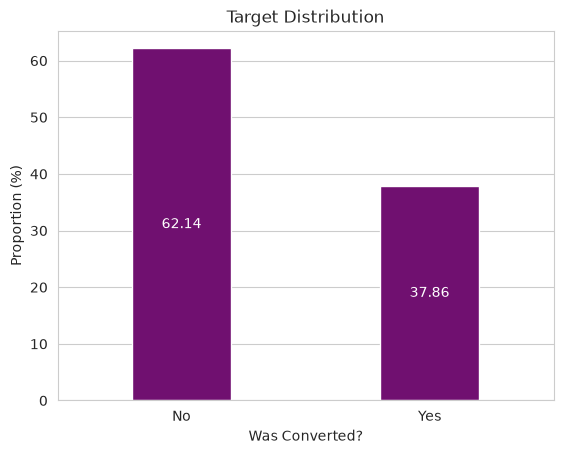

In [182]:
table = df_leads.value_counts('Converted', normalize=True) * 100 # type: ignore
ax = sns.barplot(
  table, # type: ignore
  width=0.4,
  color='purple',
)
plt.xticks([0, 1],['No', 'Yes'])
for container in ax.containers:
    ax.bar_label(container=container, fmt='%.2f', label_type="center", color='white') # type: ignore
plt.title("Target Distribution")
plt.ylabel("Proportion (%)")
plt.xlabel("Was Converted?")